<a href="https://colab.research.google.com/github/iancheung2/HAM10000-Training-and-Validation/blob/main/Copy_of_Skin_Disease_resnet50V2_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================
# Skin Disease Classification (EfficientNetB0)
# ==============================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# 2. Imports
# ----------------------------
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# 3. Dataset Path
# ----------------------------
dataset_dir = '/content/drive/MyDrive/Skin_Disease/DataSet'

# ----------------------------
# 4. Parameters
# ----------------------------
img_height, img_width = 224, 224
batch_size = 32
AUTOTUNE = tf.data.AUTOTUNE

# ----------------------------
# 5. Count Images Per Class
# ----------------------------
class_names = sorted(os.listdir(dataset_dir))

class_counts = {}

for class_name in class_names:
    class_path = os.path.join(dataset_dir, class_name)

    # Count only image files
    num_images = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    class_counts[class_name] = num_images

# ----------------------------
# 6. Print Table
# ----------------------------
df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Samples"]
)

print("\n📊 Dataset Distribution:\n")
print(df_counts)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📊 Dataset Distribution:

                        Class  Number of Samples
0           Actinic keratosis                100
1           Atopic_Dermatitis                 81
2            Benign_keratosis                100
3              Dermatofibroma                100
4           Melanocytic nevus                100
5                    Melanoma                100
6     Squamous cell carcinoma                100
7  Tinea Ringworm Candidiasis                 64
8             Vascular lesion                100


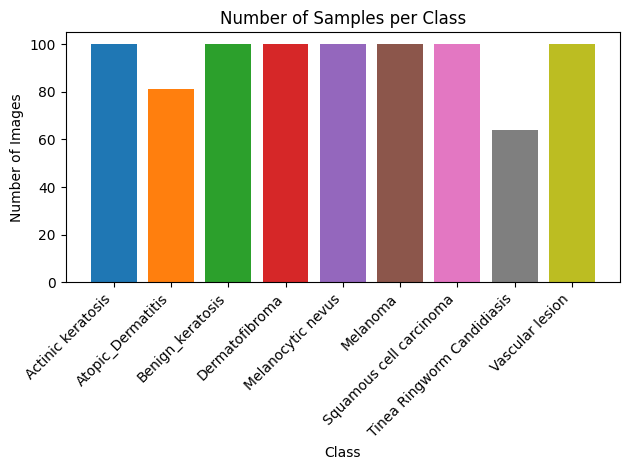

In [ ]:
# ----------------------------
# 7. Plot Bar Chart
# ----------------------------
plt.figure()

colors = plt.cm.tab10(range(len(df_counts)))  # nice distinct colors

plt.bar(df_counts["Class"], df_counts["Number of Samples"], color=colors)

plt.xticks(rotation=45, ha='right')
plt.title("Number of Samples per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
fig = plt.gcf()
fig.savefig("class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ----------------------------
# 8. Load Dataset (80/20 Split)
# ----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\n✅ Classes detected:", class_names)
print("✅ Number of classes:", num_classes)

# ----------------------------
# 9. Optimize Dataset Pipeline
# ----------------------------
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ----------------------------
# 10. Preprocessing (No preprocessing applied here, will be done per model)
# ----------------------------
# Removed: from tensorflow.keras.applications.efficientnet import preprocess_input
# Removed: train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
# Removed: val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

print("\n🚀 Datasets loaded and optimized (no model-specific preprocessing applied yet)!")

Found 845 files belonging to 9 classes.
Using 676 files for training.
Found 845 files belonging to 9 classes.
Using 169 files for validation.

✅ Classes detected: ['Actinic keratosis', 'Atopic_Dermatitis', 'Benign_keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']
✅ Number of classes: 9

🚀 Datasets loaded and optimized (no model-specific preprocessing applied yet)!


In [ ]:
from tensorflow.keras import layers

# ----------------------------
# 6. Data Augmentation
# ----------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# Removed: EfficientNetB0 specific preprocessing and model training
# This cell now only defines the data_augmentation layer used by ResNet50V2 setup.

## Using ResNet50V2 as an alternative model

In [ ]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess_input

# Re-load and preprocess datasets specifically for ResNet50V2
# It's important to start with the raw dataset again to apply correct preprocessing
print("Re-loading datasets for ResNet50V2 preprocessing...")

train_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds_resnet = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Optimize dataset pipeline (cache, shuffle, prefetch)
train_ds_resnet = train_ds_resnet.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_resnet = val_ds_resnet.cache().prefetch(buffer_size=AUTOTUNE)

# Apply augmentation ONLY on training data (using the same augmentation defined earlier)
train_ds_resnet = train_ds_resnet.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

# Apply ResNet50V2 specific preprocessing
train_ds_resnet = train_ds_resnet.map(lambda x, y: (resnet_preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
val_ds_resnet = val_ds_resnet.map(lambda x, y: (resnet_preprocess_input(x), y), num_parallel_calls=AUTOTUNE)

# Final prefetch for performance
train_ds_resnet = train_ds_resnet.prefetch(buffer_size=AUTOTUNE)
val_ds_resnet = val_ds_resnet.prefetch(buffer_size=AUTOTUNE)

print("🚀 ResNet50V2 datasets ready for training!")

Re-loading datasets for ResNet50V2 preprocessing...
Found 845 files belonging to 9 classes.
Using 676 files for training.
Found 845 files belonging to 9 classes.
Using 169 files for validation.
🚀 ResNet50V2 datasets ready for training!


In [ ]:
# Build ResNet50V2 Model
base_model_resnet = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_height, img_width, 3)
)

# 🔒 Freeze most layers for initial training
# Adjust freezing strategy as needed for ResNet50V2
for layer in base_model_resnet.layers[:-30]: # Freezing more layers initially for ResNet
    layer.trainable = False

# Unfreeze top layers only for fine-tuning
for layer in base_model_resnet.layers[-30:]: # Fine-tuning more layers at the top
    layer.trainable = True

# Add custom top layers
x = base_model_resnet.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x) # Improves stability
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs_resnet = layers.Dense(num_classes, activation='softmax')(x)

model_resnet = tf.keras.Model(inputs=base_model_resnet.input, outputs=outputs_resnet)

# Compile the new model
model_resnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,099,849 (91.93 MB)

 Trainable params: 14,974,473 (57.12 MB)

 Non-trainable params: 9,125,376 (34.81 MB)

In [ ]:
import tensorflow as tf

# Define callbacks for early stopping
callbacks = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

# Train ResNet50V2 Model
print("\nStarting training for ResNet50V2...")
history_resnet = model_resnet.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=20, # Use the same number of epochs, EarlyStopping will manage it
    callbacks=callbacks # Use the same callbacks
)


Starting training for ResNet50V2...
Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 921ms/step - accuracy: 0.2766 - loss: 2.3212 - val_accuracy: 0.3432 - val_loss: 1.8402
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 335ms/step - accuracy: 0.5592 - loss: 1.2986 - val_accuracy: 0.4438 - val_loss: 1.5785
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 301ms/step - accuracy: 0.6731 - loss: 0.9478 - val_accuracy: 0.5148 - val_loss: 1.3750
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 296ms/step - accuracy: 0.7692 - loss: 0.7105 - val_accuracy: 0.6036 - val_loss: 1.1838
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 318ms/step - accuracy: 0.7914 - loss: 0.5960 - val_accuracy: 0.6331 - val_loss: 1.1108
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 285ms/step - accuracy: 0.8136 - loss: 0.5072 - val_accuracy: 0.6272 - val_loss: 1.0530
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 316ms/step - accuracy: 0.8521 - loss: 0.4305 - val_accuracy: 0.6627 - val_loss: 0.9765
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 381ms/step - accuracy

---

Now that the `ResNet50V2` model has been trained, you can evaluate its performance using the same metrics and plotting functions as before. Remember to pass `model_resnet`, `train_ds_resnet`, `val_ds_resnet`, and `history_resnet` to the respective functions.

**Count Samples Before and After Augmentation**

In [ ]:
# ----------------------------
# Count number of samples for ResNet50V2 datasets
# ----------------------------

def count_images(dataset):
    total = 0
    # Iterate through the dataset to count actual images
    for images, labels in dataset:
        total += images.shape[0]
    return total

num_samples_train_resnet = count_images(train_ds_resnet)
num_samples_val_resnet = count_images(val_ds_resnet)

print(f"Number of training samples (ResNet50V2): {num_samples_train_resnet}")
print(f"Number of validation samples (ResNet50V2): {num_samples_val_resnet}")

# ----------------------------
# Put in a DataFrame
# ----------------------------
import pandas as pd

df_counts_resnet = pd.DataFrame({
    "Dataset": ["Train (ResNet50V2)", "Validation (ResNet50V2)"],
    "Number of Samples": [num_samples_train_resnet, num_samples_val_resnet]
})

print("\n📊 Dataset Samples for ResNet50V2:")
print(df_counts_resnet)


Number of training samples (ResNet50V2): 676
Number of validation samples (ResNet50V2): 169

📊 Dataset Samples for ResNet50V2:
                   Dataset  Number of Samples
0       Train (ResNet50V2)                676
1  Validation (ResNet50V2)                169


In [ ]:
# ----------------------------
# 9. Extract predictions and true labels for ResNet50V2
# ----------------------------
def get_labels_and_predictions(dataset, model):
    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

# For training dataset (ResNet50V2)
y_true_train_resnet, y_pred_train_resnet = get_labels_and_predictions(train_ds_resnet, model_resnet)

# For validation dataset (ResNet50V2)
y_true_val_resnet, y_pred_val_resnet = get_labels_and_predictions(val_ds_resnet, model_resnet)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133

In [ ]:
# ----------------------------
# Define metrics_df function
# ----------------------------
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def metrics_df(y_true, y_pred, dataset_name):
    """Compute key classification metrics and return as DataFrame."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # Optional: confusion matrix display
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix ({dataset_name}):\n", cm)

    # Return DataFrame with metrics
    df = pd.DataFrame({
        'Dataset': [dataset_name],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1-Score': [f1]
    })
    return df


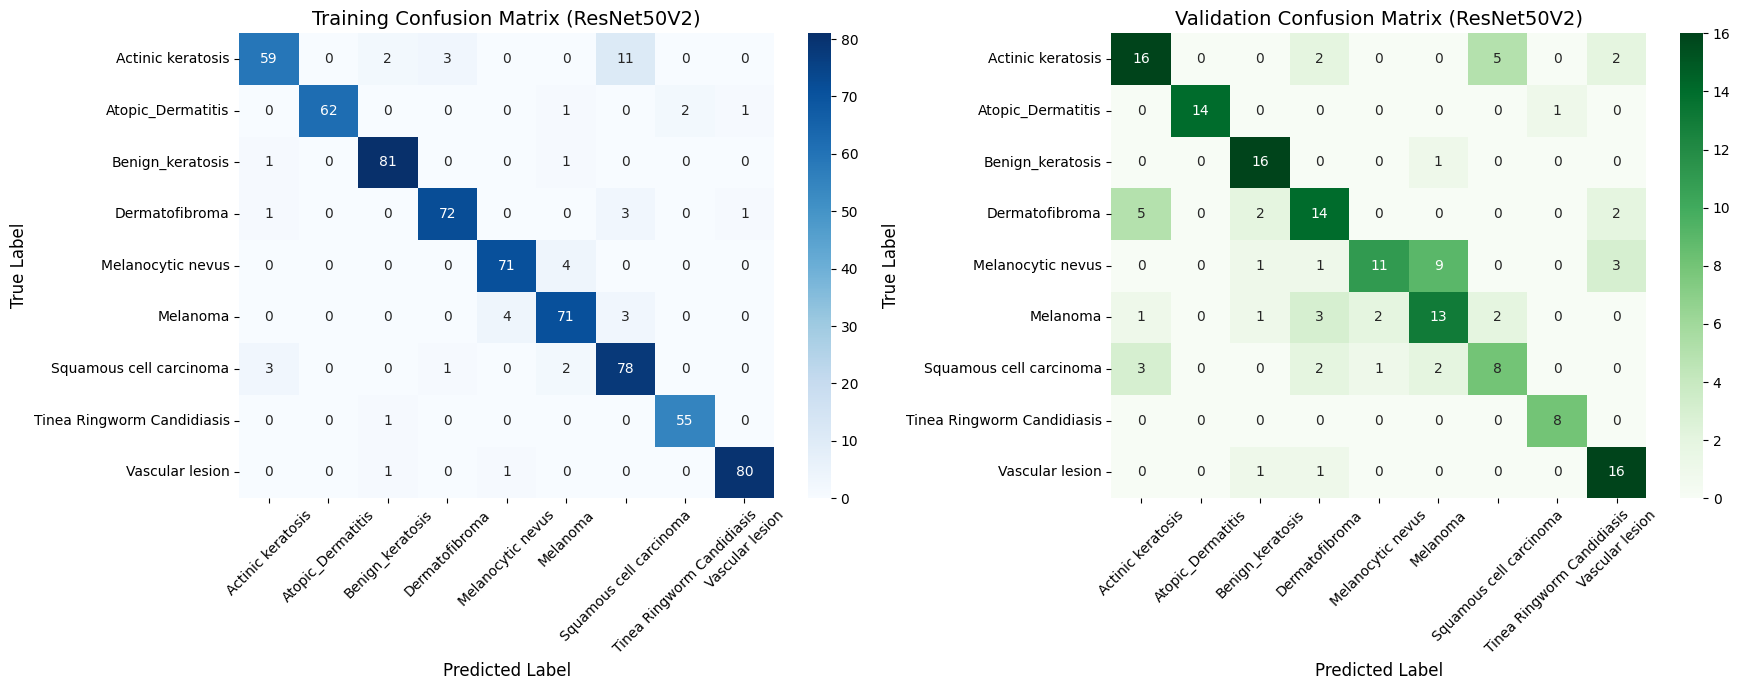

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrices(y_true_train, y_pred_train, y_true_val, y_pred_val, class_names):
    """
    Plot training and validation confusion matrices as side-by-side subplots.
    Returns the figure object for saving.
    """
    # Compute confusion matrices
    cm_train = confusion_matrix(y_true_train, y_pred_train)
    cm_val = confusion_matrix(y_true_val, y_pred_val)

    # Set up subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Training CM
    sns.heatmap(
        cm_train, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[0]
    )
    axes[0].set_title("Training Confusion Matrix (ResNet50V2)", fontsize=14)
    axes[0].set_xlabel("Predicted Label", fontsize=12)
    axes[0].set_ylabel("True Label", fontsize=12)
    axes[0].tick_params(axis='x', labelsize=10, rotation=45)
    axes[0].tick_params(axis='y', labelsize=10, rotation=0)

    # Validation CM
    sns.heatmap(
        cm_val, annot=True, fmt='d', cmap='Greens',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[1]
    )
    axes[1].set_title("Validation Confusion Matrix (ResNet50V2)", fontsize=14)
    axes[1].set_xlabel("Predicted Label", fontsize=12)
    axes[1].set_ylabel("True Label", fontsize=12)
    axes[1].tick_params(axis='x', labelsize=10, rotation=45)
    axes[1].tick_params(axis='y', labelsize=10, rotation=0)

    fig.tight_layout()  # fix spacing
    return fig  # return figure for saving

# ----------------------------
# Example usage for ResNet50V2
# ----------------------------
fig_resnet_cm = plot_confusion_matrices(y_true_train_resnet, y_pred_train_resnet, y_true_val_resnet, y_pred_val_resnet, class_names)

# Save figure
fig_resnet_cm.savefig("confusion_matrix_resnet_training_testing.png", dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
# --- Generate ResNet50V2 Metrics ---
df_train_results_resnet = metrics_df(y_true_train_resnet, y_pred_train_resnet, "Training (ResNet50V2)")
df_val_results_resnet = metrics_df(y_true_val_resnet, y_pred_val_resnet, "Validation (ResNet50V2)")

# Combine them into one table
df_final_results_resnet = pd.concat([df_train_results_resnet, df_val_results_resnet], ignore_index=True)

print("\n📊 Final Comparison Metrics for ResNet50V2:")
print(df_final_results_resnet)



Confusion Matrix (Training (ResNet50V2)):
 [[59  0  2  3  0  0 11  0  0]
 [ 0 62  0  0  0  1  0  2  1]
 [ 1  0 81  0  0  1  0  0  0]
 [ 1  0  0 72  0  0  3  0  1]
 [ 0  0  0  0 71  4  0  0  0]
 [ 0  0  0  0  4 71  3  0  0]
 [ 3  0  0  1  0  2 78  0  0]
 [ 0  0  1  0  0  0  0 55  0]
 [ 0  0  1  0  1  0  0  0 80]]

Confusion Matrix (Validation (ResNet50V2)):
 [[16  0  0  2  0  0  5  0  2]
 [ 0 14  0  0  0  0  0  1  0]
 [ 0  0 16  0  0  1  0  0  0]
 [ 5  0  2 14  0  0  0  0  2]
 [ 0  0  1  1 11  9  0  0  3]
 [ 1  0  1  3  2 13  2  0  0]
 [ 3  0  0  2  1  2  8  0  0]
 [ 0  0  0  0  0  0  0  8  0]
 [ 0  0  1  1  0  0  0  0 16]]

📊 Final Comparison Metrics for ResNet50V2:
                   Dataset  Accuracy  Precision    Recall  F1-Score
0    Training (ResNet50V2)  0.930473   0.932474  0.930473  0.930341
1  Validation (ResNet50V2)  0.686391   0.693500  0.686391  0.679927


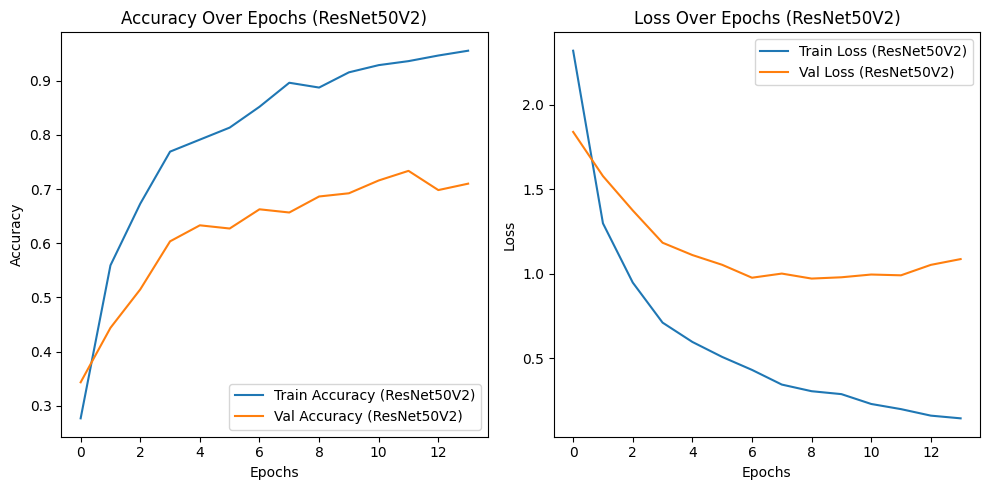

In [ ]:
# ----------------------------
# 10. Accuracy & Loss Plots for ResNet50V2
# ----------------------------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy (ResNet50V2)')
plt.plot(history_resnet.history['val_accuracy'], label='Val Accuracy (ResNet50V2)')
plt.title('Accuracy Over Epochs (ResNet50V2)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_resnet.history['loss'], label='Train Loss (ResNet50V2)')
plt.plot(history_resnet.history['val_loss'], label='Val Loss (ResNet50V2)')
plt.title('Loss Over Epochs (ResNet50V2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('accuracy_loss_resnet.png')
plt.show()


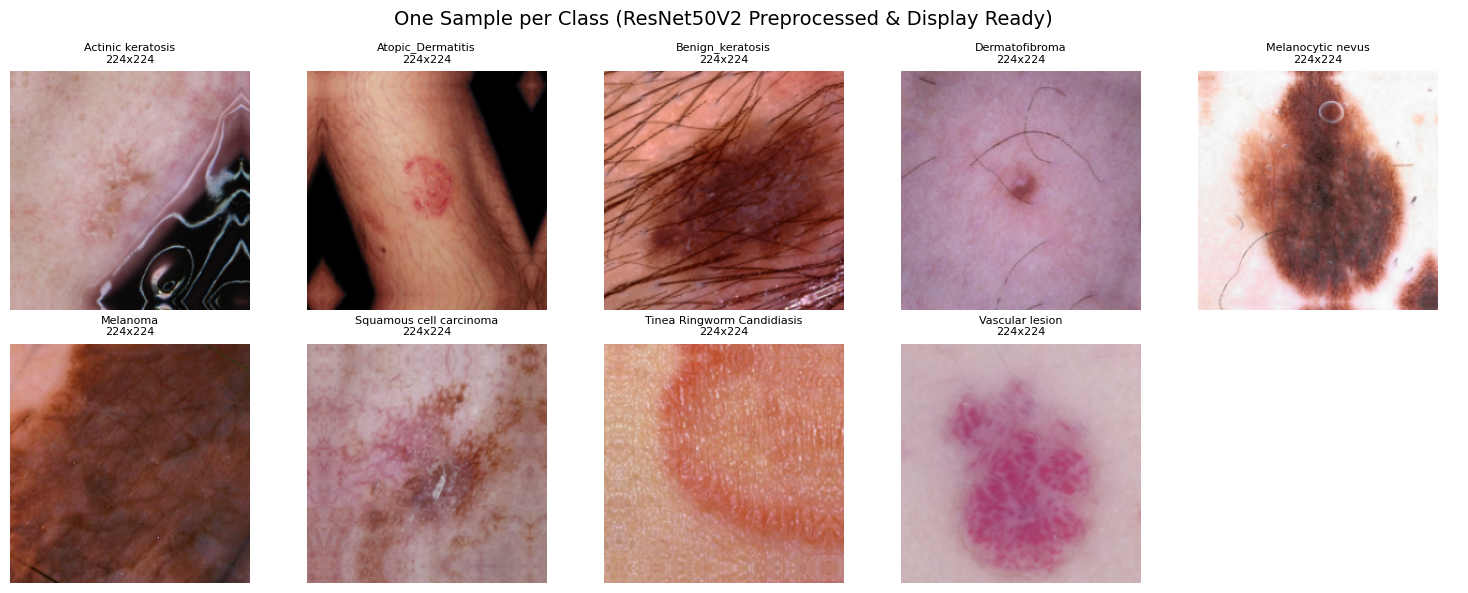

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess_input # Import ResNet-specific preprocessing

# ----------------------------
# Parameters
# ----------------------------
samples_per_class = 1       # one image per class
img_height, img_width = 224, 224  # ResNet50V2 input size

# ----------------------------
# Function to extract one sample per class from training dataset
# ----------------------------
def get_one_sample_from_dataset(dataset, class_index):
    """Return one image from a given class index in the dataset."""
    for batch_images, batch_labels in dataset:
        batch_labels_np = batch_labels.numpy()
        batch_images_np = batch_images.numpy()
        for i, label in enumerate(batch_labels_np):
            if label == class_index:
                return batch_images_np[i]
    return None

# ----------------------------
# Plotting as a square matrix for ResNet50V2
# ----------------------------
num_classes = len(class_names)
cols = min(5, num_classes)              # max 5 columns
rows = (num_classes + cols - 1) // cols # compute required rows

fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))

# Flatten axes for easy iteration
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    # Get image from the ResNet-specific training dataset
    img = get_one_sample_from_dataset(train_ds_resnet, idx)
    if img is None:
        continue

    # Note: train_ds_resnet already has preprocessing applied, so we should display it as is
    # However, for visualization, it's often better to reverse the preprocessing or
    # display an unprocessed version if available. Since we need to use 'uint8' for imshow,
    # and `preprocess_input` often normalizes to [-1, 1], we need to convert it back.
    # For simplicity, if train_ds_resnet is already preprocessed, we'll try to scale it back
    # for display purposes. If not, it assumes the data is in the 0-255 range.

    # If the image was preprocessed to [-1, 1] or [0, 1], rescale for display
    img_display = img
    if img.min() < 0 or img.max() > 1: # Heuristic to check if it might be preprocessed
        img_display = (img * 0.5 + 0.5) * 255 # If in [-1, 1] range, convert to [0, 255]
    elif img.max() <= 1: # If in [0, 1] range, convert to [0, 255]
        img_display = img * 255

    axes[idx].imshow(img_display.astype("uint8"))
    axes[idx].set_title(f"{class_name}\n{img_height}x{img_width}", fontsize=8)
    axes[idx].axis("off")

# Hide any unused axes
for j in range(idx+1, len(axes)):
    axes[j].axis("off")

plt.suptitle("One Sample per Class (ResNet50V2 Preprocessed & Display Ready)", fontsize=14)
plt.tight_layout()

# Save the figure
fig.savefig("sample_images_matrix_resnet.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
def plot_roc_subplots(train_ds, val_ds, model, num_classes):
    """
    Plot ROC curves for training and validation datasets side by side.

    Each dataset gets its own subplot.
    """
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    import numpy as np

    # Helper to get true labels and predicted probabilities
    y_true_train, y_probs_train = get_probabilities_and_labels(train_ds, model)
    y_true_val, y_probs_val = get_probabilities_and_labels(val_ds, model)

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # ----------------------------
    # Training ROC
    # ----------------------------
    ax = axes[0]
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true_train, y_probs_train[:, 1])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    else:
        y_true_bin = label_binarize(y_true_train, classes=range(num_classes))
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_train[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title("Training ROC")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(True)

    # ----------------------------
    # Validation ROC
    # ----------------------------
    ax = axes[1]
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true_val, y_probs_val[:, 1])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
    else:
        y_true_bin = label_binarize(y_true_val, classes=range(num_classes))
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_val[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title("Validation ROC")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(True)

    plt.tight_layout()
    return fig

In [ ]:
def get_probabilities_and_labels(dataset, model):
    import numpy as np
    y_true = []
    y_pred_probs = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true.append(labels.numpy())
        y_pred_probs.append(probs)

    y_true = np.concatenate(y_true)
    y_pred_probs = np.concatenate(y_pred_probs)

    return y_true, y_pred_probs


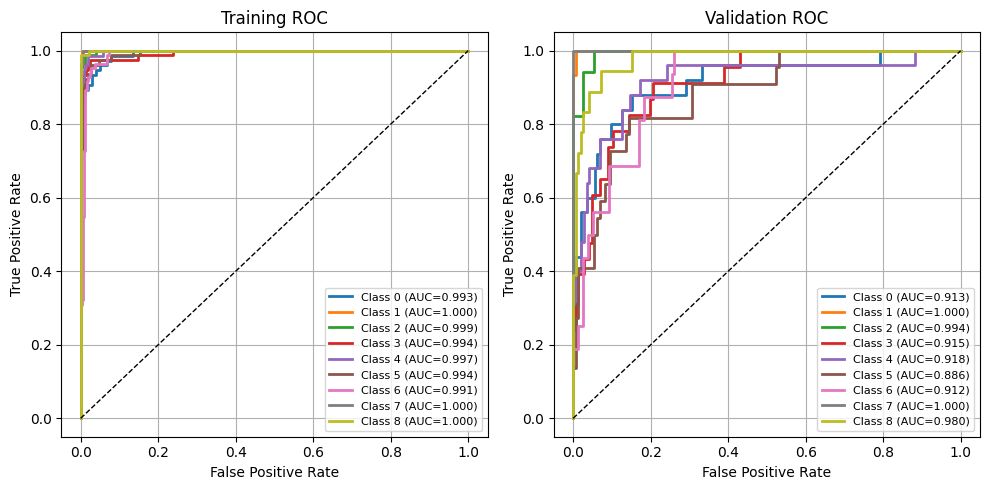

In [ ]:
# Generate the ROC figure for ResNet50V2
fig_resnet_roc = plot_roc_subplots(train_ds_resnet, val_ds_resnet, model_resnet, num_classes)

# Save the figure to a file
fig_resnet_roc.savefig("roc_resnet_training_validation.png", dpi=300, bbox_inches='tight')

# Optionally display it
plt.show()


In [ ]:
# ----------------------------
# Count number of images in training and validation sets for ResNet50V2
# ----------------------------

def count_images(dataset):
    total = 0
    for images, labels in dataset:
        total += images.shape[0]  # batch size
    return total

num_train_images_resnet = count_images(train_ds_resnet)
num_val_images_resnet   = count_images(val_ds_resnet)

print(f"Number of training images (ResNet50V2): {num_train_images_resnet}")
print(f"Number of validation/testing images (ResNet50V2): {num_val_images_resnet}")


Number of training images (ResNet50V2): 676
Number of validation/testing images (ResNet50V2): 169
